In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu
import xlsxwriter

In [2]:
df = pd.read_excel('diplom.xlsx', sheet_name = 'Данные')
df

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174
...,...,...,...,...
37984,297586,NaN,NaN,NaT
37985,297593,179230.0,5755.0,2022-06-05 19:40:07.096
37986,297595,192530.0,4448.0,2022-07-09 18:43:02.810
37987,297601,183888.0,1746.0,2022-06-20 06:24:42.155


In [3]:
df_1 = pd.read_excel('diplom.xlsx', sheet_name = 'Clients')
df_1

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015
...,...,...,...,...
55600,193038,2022-07-09 00:31:25.196,0,1015
55601,244069,2022-08-08 00:12:31.319,1,991
55602,189084,2022-06-29 04:34:42.610,1,439
55603,182758,2022-06-13 11:28:37.856,1,573


In [4]:
df_2 = pd.read_excel('diplom.xlsx', sheet_name = 'Region_dict')
df_2

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир
...,...,...
61,3987,Москва
62,6543,Москва
63,8543,Москва
64,9121,Москва


In [5]:
# Проверяем, есть ли в df хоть одно пустое значение
print('Пропуски df')
print(df.isna().sum())

Пропуски df
id_order          0
id_client       588
amt_payment    2144
dtime_pay      2429
dtype: int64


In [6]:
# Проверяем, есть ли в df_1 хоть одно пустое значение
print('Пропуски df_1')
print(df_1.isna().sum())

Пропуски df_1
id_client             0
dtime_ad            249
nflag_test            0
id_trading_point      0
dtype: int64


In [7]:
# Проверяем, есть ли в df_2 хоть одно пустое значение
print('Пропуски df_2')
print(df_2.isna().sum())

Пропуски df_2
id_trading_point    0
city                0
dtype: int64


In [8]:
# Удаляем пропуски df, так как они составляют менее 10%, что не повлияет на анализ
df_cleaned = df.dropna()
print('Пропуски')
print(df_cleaned.isna().sum())

Пропуски
id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64


In [9]:
# Удаляем пропуски df_1, так как они составляют менее 10%, что не повлияет на анализ
df_cleaned_1 = df_1.dropna()
print('Пропуски')
print(df_cleaned.isna().sum())

Пропуски
id_order       0
id_client      0
amt_payment    0
dtime_pay      0
dtype: int64


In [10]:
# Группировка по городам и подсчёт количества торговых точек
city_counts = df_2['city'].value_counts()
print("\nКоличество торговых точек по городам:")
print(city_counts)


Количество торговых точек по городам:
city
Москва              11
Санкт-Петербург     11
Казань               6
Новосибирск          6
Красноярск           5
Краснодар            4
Самара               4
Саратов              2
Сочи                 2
Мурманск             2
Ярославль            1
Дмитров              1
Волгоград            1
Сахалинск            1
Ростов-на-Дону       1
Великий Новгород     1
Тольятти             1
Тюмень               1
Нижний Новгород      1
Владимир             1
Ростов Великий       1
Чехов                1
Петрозаводск         1
Name: count, dtype: int64


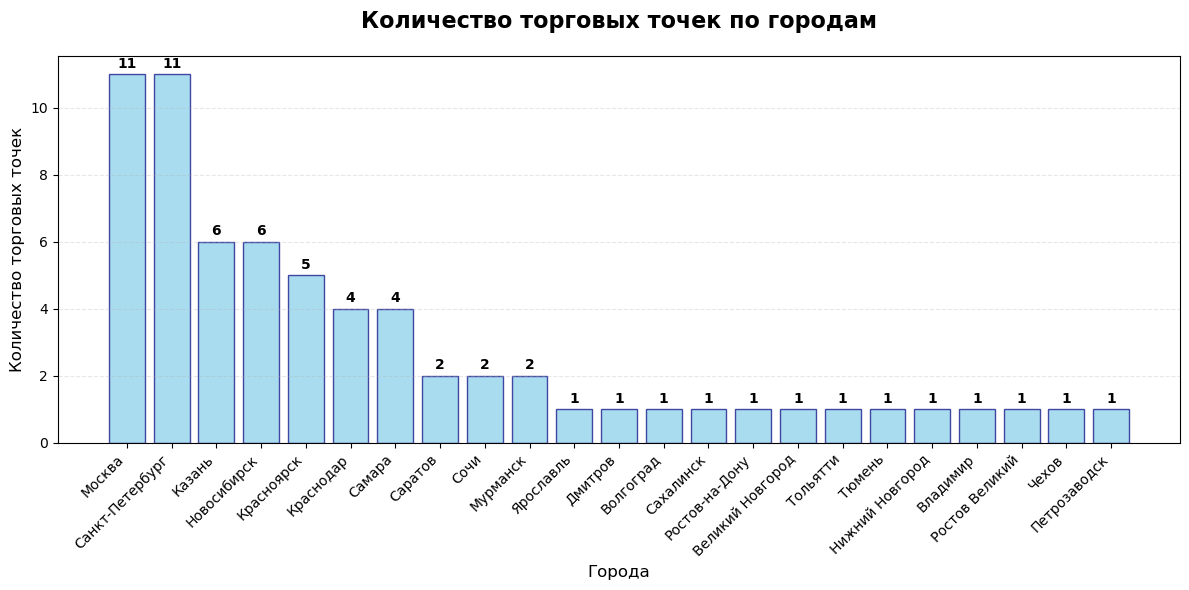

In [11]:
# Визуализация — вертикальная столбчатая диаграмма
plt.figure(figsize=(12, 6))
bars = plt.bar(city_counts.index, city_counts.values, color='skyblue', edgecolor='navy', alpha=0.7)
# Настройка графика
plt.title('Количество торговых точек по городам', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Города', fontsize=12)
plt.ylabel('Количество торговых точек', fontsize=12)
# Поворот подписей на оси X, если названия длинные
plt.xticks(rotation=45, ha='right')
# Добавление значений на столбцы
for bar, value in zip(bars, city_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        str(value),
        ha='center',
        va='bottom',
        fontweight='bold'
    )
# Улучшение внешнего вида
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Вывод: Больше всего точек в Москве и СПБ (11), в два раза меньше в Казани, Новосиибирске (6), Красноярске (5), Краснодаре, Самаре (4).
# В остальных городах количество значительно меньше (2, 1), соответственно нужно будет обратить внимание на это при дальнейшем анализе.

In [13]:
# Группируем по клиенту и суммируем платежи
payments_agg = df_cleaned.groupby('id_client')['amt_payment'].sum().reset_index()
payments_agg

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0
...,...,...
28378,209630.0,6927.0
28379,209631.0,2090.0
28380,209632.0,2775.0
28381,209633.0,1673.0


In [14]:
# Объединяем с таблицей клиентов, сохраняя всех клиентов из клиентской таблицы (left join)
clients_with_payments = pd.merge(df_cleaned_1, payments_agg, on='id_client', how='left')
clients_with_payments

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,226069,2022-07-11 16:28:38.511,1,54,NaN
2,183981,2022-06-16 12:23:59.289,1,991,6322.0
3,322530,2022-07-08 08:56:08.714,0,1015,NaN
4,254313,2022-06-19 22:18:01.770,1,453,NaN
...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0
55352,244069,2022-08-08 00:12:31.319,1,991,NaN
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0


In [15]:
# Заполняем нулями суммы покупок для клиентов без платежей
clients_with_payments['amt_payment'] = clients_with_payments['amt_payment'].fillna(0)
clients_with_payments

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0
1,226069,2022-07-11 16:28:38.511,1,54,0.0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0
3,322530,2022-07-08 08:56:08.714,0,1015,0.0
4,254313,2022-06-19 22:18:01.770,1,453,0.0
...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0
55352,244069,2022-08-08 00:12:31.319,1,991,0.0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0


In [16]:
# Подтягиваем город к торговой точке, используем left join, чтобы сохранить все строки из clients_with_payments
result = pd.merge(clients_with_payments, df_2, on='id_trading_point', how='left')
result

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург
...,...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0,Краснодар
55352,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург


In [17]:
# Добавляем флаг платежа 
result['flag_payment'] = (result['amt_payment'] != 0).astype(int)
result

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
3,322530,2022-07-08 08:56:08.714,0,1015,0.0,Краснодар,0
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55351,193038,2022-07-09 00:31:25.196,0,1015,5846.0,Краснодар,1
55352,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург,1


In [18]:
# Функция для t‑критерия Стьюдента
def test_calc(r1, r2, alpha=0.05):
    """
    Вычисляет t‑критерий Стьюдента и p‑value для сравнения средних.    
    Параметры:
    r1 — первая выборка (nflag_test = 0)
    r2 — вторая выборка (nflag_test = 1)
    alpha — уровень значимости (по умолчанию 5 %)
    """
    t_stat, p_value = stats.ttest_ind(r1, r2, equal_var=False)  # Welch's t‑test    
    print(f"t‑критерий: {t_stat:.4f}")
    print(f"p‑value: {p_value:.4f}")   
    if p_value < alpha:
        print("Вывод: есть статистически значимая разница между средними (p < α)")
    else:
        print("Вывод: нет статистически значимой разницы между средними (p ≥ α)")    
    return t_stat, p_value

In [19]:
# Функция для критерия Манна‑Уитни
def mann_whitney_func(r1, r2, alpha=0.05):
    """
    Вычисляет критерий Манна‑Уитни и p‑value для сравнения распределений.    
    Параметры:
    r1 — первая выборка (flag_payment = 0)
    r2 — вторая выборка (flag_payment = 1)
    alpha — уровень значимости (по умолчанию 5 %)
    """
    u_stat, p_value = stats.mannwhitneyu(r1, r2, alternative='two-sided')    
    print(f"U‑статистика: {u_stat:.4f}")
    print(f"p‑value: {p_value:.4f}")   
    if p_value < alpha:
        print("Вывод: распределения статистически значимо различаются (p < α)")
    else:
        print("Вывод: распределения не различаются статистически значимо (p ≥ α)")    
    return u_stat, p_value

In [20]:
# Чистка неверно заполненных точек
# Список торговых точек, где не было платежей ни в одной группе
zero_payment_points = []
# Список торговых точек с отсутствующей группой
empty_group_points = []
# Группируем по торговым точкам
grouped = result.groupby('id_trading_point')
for point_id, group in grouped:
    # Проверка на нулевые платежи в группах
    test_group = group[group['nflag_test'] == 1]
    control_group = group[group['nflag_test'] == 0]    
    # Если в какой‑либо группе сумма платежей равна 0
    if (test_group['amt_payment'].sum() == 0 or
        control_group['amt_payment'].sum() == 0):
        zero_payment_points.append(point_id)   
    # Если какая‑либо группа отсутствует полностью
    if len(test_group) == 0 or len(control_group) == 0:
        empty_group_points.append(point_id)
print(f"Торговые точки с нулевыми платежами: {zero_payment_points}")
print(f"Торговые точки с отсутствующей группой: {empty_group_points}")

Торговые точки с нулевыми платежами: [1, 4, 7, 13, 23, 26, 46, 228, 603, 739, 800, 810, 866, 1015, 1099]
Торговые точки с отсутствующей группой: [228, 603, 739, 800, 810, 866, 1015, 1099]


In [21]:
# Отбор корректных данных
# Объединяем списки проблемных точек
problematic_points = set(zero_payment_points + empty_group_points)
# Фильтруем DataFrame, исключая проблемные точки
filtered_df = result[~result['id_trading_point'].isin(problematic_points)].copy()
print(f"Исходное количество записей: {len(result)}")
print(f"Количество записей после фильтрации: {len(filtered_df)}")

Исходное количество записей: 55356
Количество записей после фильтрации: 45318


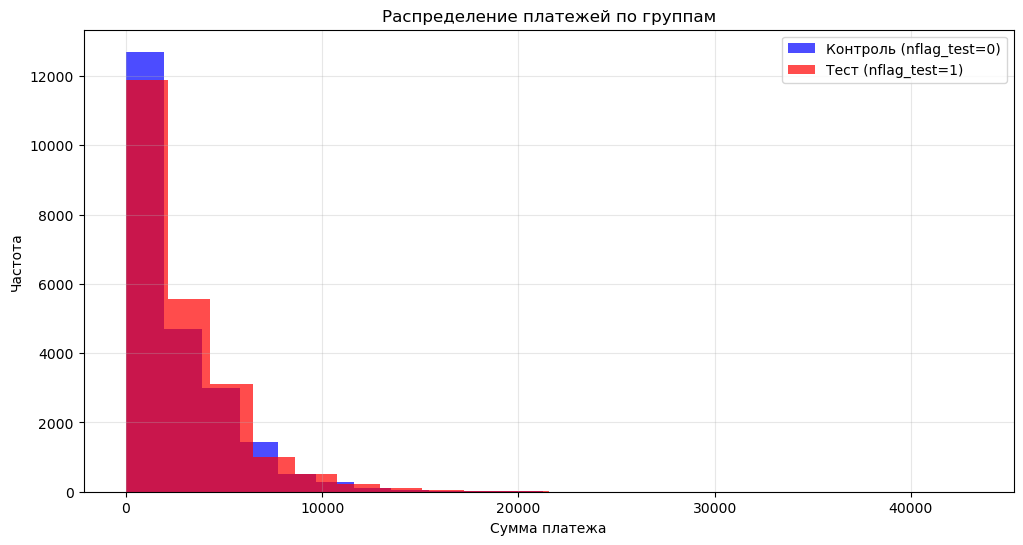

In [22]:
# Визуализация гистограммы платежей
plt.figure(figsize=(12, 6))
# Разделяем данные по группам
test_data = filtered_df[filtered_df['nflag_test'] == 1]['amt_payment']
control_data = filtered_df[filtered_df['nflag_test'] == 0]['amt_payment']
# Строим гистограммы
plt.hist(control_data, bins=20, alpha=0.7, label='Контроль (nflag_test=0)', color='blue')
plt.hist(test_data, bins=20, alpha=0.7, label='Тест (nflag_test=1)', color='red')
plt.xlabel('Сумма платежа')
plt.ylabel('Частота')
plt.title('Распределение платежей по группам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
# Анализ результатов A/B‑теста
# Сравнение средних платежей
test_payments = filtered_df[filtered_df['nflag_test'] == 1]['amt_payment']
control_payments = filtered_df[filtered_df['nflag_test'] == 0]['amt_payment']
print("Сравнение средних платежей:")
test_calc(control_payments, test_payments)
# Сравнение конверсии в платёж
# Создаём бинарные ряды для конверсии (1 — был платёж, 0 — не было)
test_conversion = (filtered_df[filtered_df['nflag_test'] == 1]['flag_payment'] == 1).astype(int)
control_conversion = (filtered_df[filtered_df['nflag_test'] == 0]['flag_payment'] == 1).astype(int)
print("\nСравнение конверсии в платёж:")
test_calc(control_conversion, test_conversion)

Сравнение средних платежей:
t‑критерий: -9.4527
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)

Сравнение конверсии в платёж:
t‑критерий: -9.2824
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)


(np.float64(-9.282362400356972), np.float64(1.7284765137365496e-20))

In [24]:
# Критерий Манна‑Уитни для распределений платежей
print("\nКритерий Манна‑Уитни для платежей:")
mann_whitney_func(control_payments, test_payments)


Критерий Манна‑Уитни для платежей:
U‑статистика: 243344369.0000
p‑value: 0.0000
Вывод: распределения статистически значимо различаются (p < α)


(np.float64(243344369.0), np.float64(3.008345273971901e-24))

In [25]:
filtered_df

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_payment
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
5,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
...,...,...,...,...,...,...,...
55350,188702,2022-06-28 06:16:25.664,0,453,1323.0,Санкт-Петербург,1
55352,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
55353,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1
55354,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург,1


In [26]:
# Фильтруем данные только для Москвы
moscow_data = filtered_df[filtered_df['city'] == 'Москва']
moscow_data

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_payment
5,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
8,274394,2022-06-25 00:46:07.492,1,2652,0.0,Москва,0
13,201373,2022-07-29 22:27:46.612,1,6543,5009.0,Москва,1
16,205352,2022-08-08 20:59:32.806,0,2652,0.0,Москва,0
29,185585,2022-06-20 12:40:52.026,0,2652,0.0,Москва,0
...,...,...,...,...,...,...,...
55309,193774,2022-07-10 21:45:57.683,0,9121,5851.0,Москва,1
55322,200450,2022-07-27 13:37:21.523,0,2212,2989.0,Москва,1
55329,273340,2022-07-19 11:15:52.553,1,1654,0.0,Москва,0
55333,240483,2022-06-17 09:55:25.649,1,1287,0.0,Москва,0


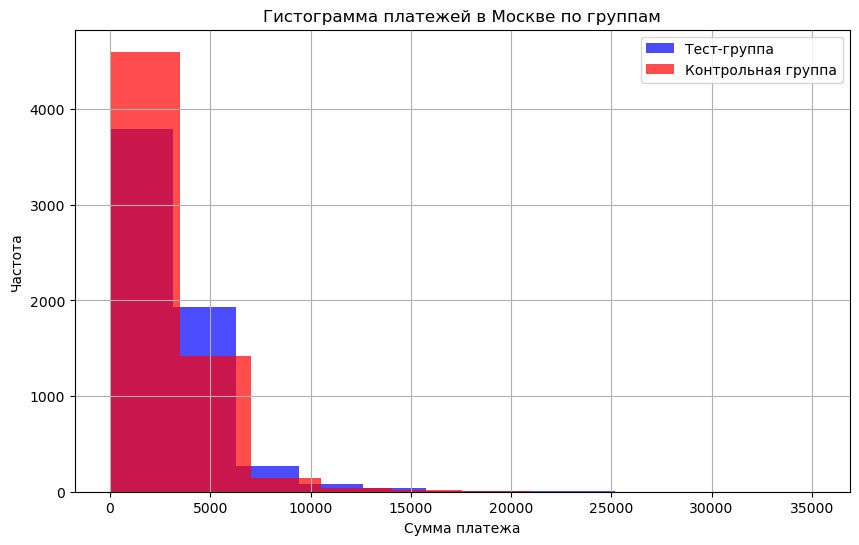

In [27]:
# Разделяем данные на группы
test_group = moscow_data[moscow_data['nflag_test'] == 1]
control_group = moscow_data[moscow_data['nflag_test'] == 0]
# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist(test_group['amt_payment'], alpha=0.7, label='Тест-группа', color='blue', bins=10)
plt.hist(control_group['amt_payment'], alpha=0.7, label='Контрольная группа', color='red', bins=10)
plt.title('Гистограмма платежей в Москве по группам')
plt.xlabel('Сумма платежа')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Анализ результатов A/B‑теста
# Сравнение средних платежей
test_payments = moscow_data[moscow_data['nflag_test'] == 1]['amt_payment']
control_payments = moscow_data[moscow_data['nflag_test'] == 0]['amt_payment']
print("Сравнение средних платежей:")
test_calc(control_payments, test_payments)
# Сравнение конверсии в платёж
# Создаём бинарные ряды для конверсии (1 — был платёж, 0 — не было)
test_conversion = (moscow_data[moscow_data['nflag_test'] == 1]['flag_payment'] == 1).astype(int)
control_conversion = (moscow_data[moscow_data['nflag_test'] == 0]['flag_payment'] == 1).astype(int)
print("\nСравнение конверсии в платёж:")
test_calc(control_conversion, test_conversion)

Сравнение средних платежей:
t‑критерий: -7.6721
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)

Сравнение конверсии в платёж:
t‑критерий: -6.1905
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)


(np.float64(-6.19047063650437), np.float64(6.18851179009111e-10))

In [29]:
# Критерий Манна‑Уитни для распределений платежей
print("\nКритерий Манна‑Уитни для платежей:")
mann_whitney_func(control_payments, test_payments)


Критерий Манна‑Уитни для платежей:
U‑статистика: 17582441.5000
p‑value: 0.0000
Вывод: распределения статистически значимо различаются (p < α)


(np.float64(17582441.5), np.float64(7.010591402203484e-16))

In [30]:
# Фильтруем данные только для СПБ
spb_data = filtered_df[filtered_df['city'] == 'Санкт-Петербург']
spb_data

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,flag_payment
4,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
9,200225,2022-07-27 00:18:47.370,0,453,4372.0,Санкт-Петербург,1
15,205357,2022-08-08 21:22:23.684,0,453,2818.0,Санкт-Петербург,1
26,248371,2022-08-02 01:44:51.638,0,112,0.0,Санкт-Петербург,0
30,277149,2022-07-15 01:31:37.312,0,394,0.0,Санкт-Петербург,0
...,...,...,...,...,...,...,...
55343,204576,2022-08-06 22:36:40.980,1,576,3552.0,Санкт-Петербург,1
55344,186456,2022-06-22 16:06:03.632,0,117,9217.0,Санкт-Петербург,1
55349,260405,2022-08-15 02:47:58.960,0,576,0.0,Санкт-Петербург,0
55350,188702,2022-06-28 06:16:25.664,0,453,1323.0,Санкт-Петербург,1


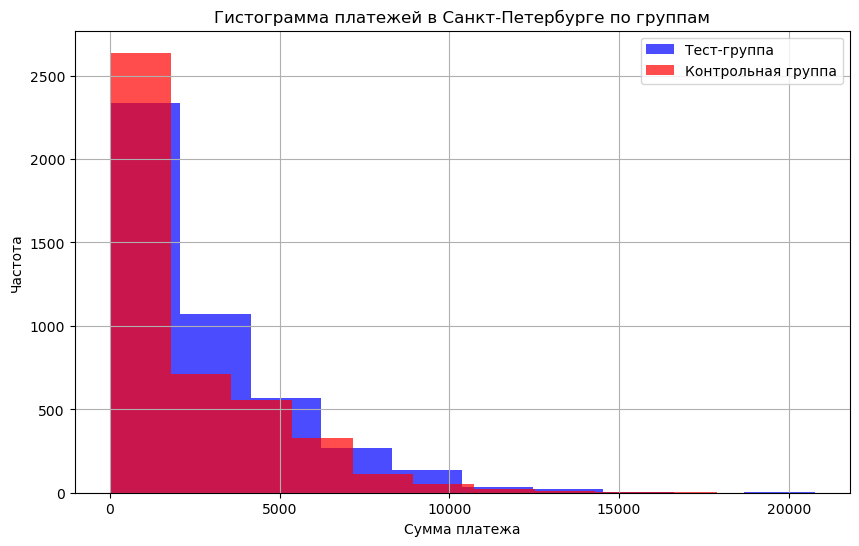

In [31]:
# Разделяем данные на группы
test_group = spb_data[spb_data['nflag_test'] == 1]
control_group = spb_data[spb_data['nflag_test'] == 0]
# Строим гистограмму
plt.figure(figsize=(10, 6))
plt.hist(test_group['amt_payment'], alpha=0.7, label='Тест-группа', color='blue', bins=10)
plt.hist(control_group['amt_payment'], alpha=0.7, label='Контрольная группа', color='red', bins=10)
plt.title('Гистограмма платежей в Санкт-Петербурге по группам')
plt.xlabel('Сумма платежа')
plt.ylabel('Частота')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Анализ результатов A/B‑теста
# Сравнение средних платежей
test_payments = spb_data[spb_data['nflag_test'] == 1]['amt_payment']
control_payments = spb_data[spb_data['nflag_test'] == 0]['amt_payment']
print("Сравнение средних платежей:")
test_calc(control_payments, test_payments)
# Сравнение конверсии в платёж
# Создаём бинарные ряды для конверсии (1 — был платёж, 0 — не было)
test_conversion = (spb_data[spb_data['nflag_test'] == 1]['flag_payment'] == 1).astype(int)
control_conversion = (spb_data[spb_data['nflag_test'] == 0]['flag_payment'] == 1).astype(int)
print("\nСравнение конверсии в платёж:")
test_calc(control_conversion, test_conversion)

Сравнение средних платежей:
t‑критерий: -8.7606
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)

Сравнение конверсии в платёж:
t‑критерий: -9.3525
p‑value: 0.0000
Вывод: есть статистически значимая разница между средними (p < α)


(np.float64(-9.352479120817705), np.float64(1.0657220952695895e-20))

In [33]:
# Критерий Манна‑Уитни для распределений платежей
print("\nКритерий Манна‑Уитни для платежей:")
mann_whitney_func(control_payments, test_payments)


Критерий Манна‑Уитни для платежей:
U‑статистика: 8809444.5000
p‑value: 0.0000
Вывод: распределения статистически значимо различаются (p < α)


(np.float64(8809444.5), np.float64(2.0392184217953754e-20))

АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Красноярск


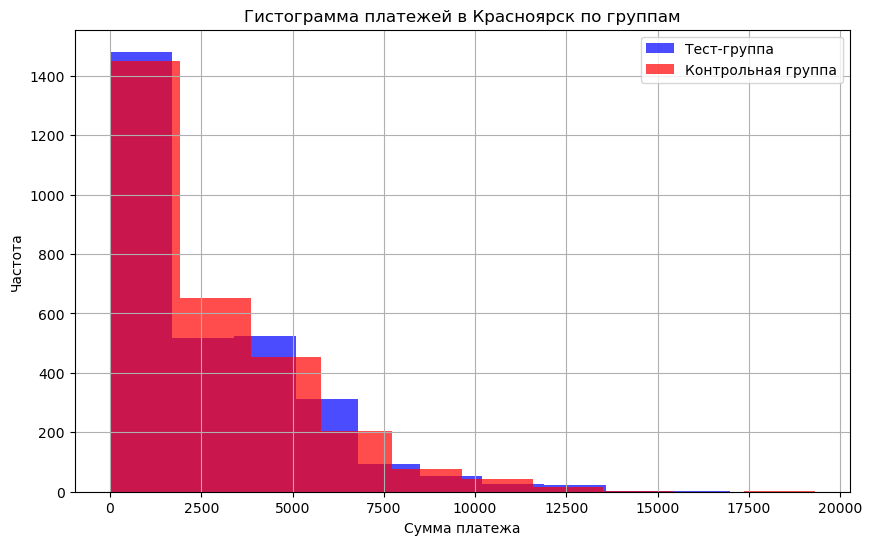

Сравнение средних платежей:
Среднее в контрольной группе: 2428.78
Среднее в тест‑группе: 2437.50
Разница: +0.36%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.56
Среднее в тест‑группе: 0.56
Разница: -0.64%

Критерий Манна‑Уитни для платежей:
Статистика U: 4413418.00
p‑значение: 0.8770
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Мурманск


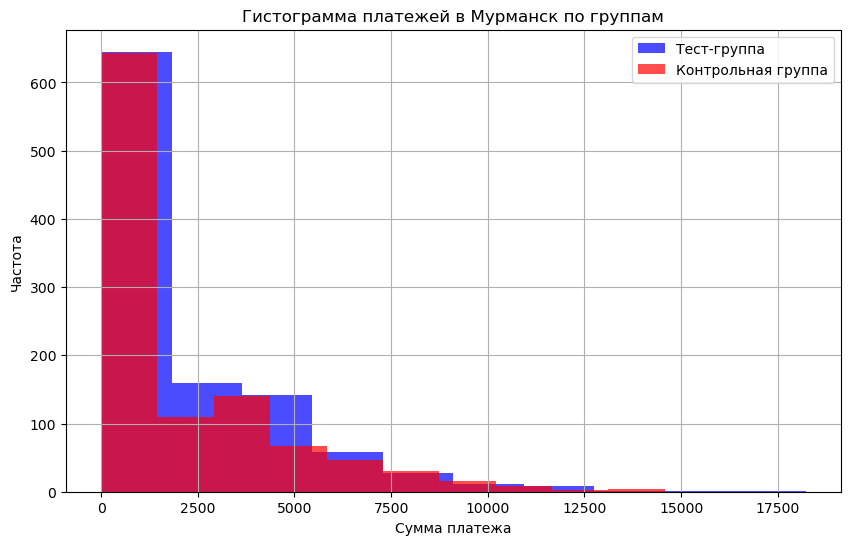

Сравнение средних платежей:
Среднее в контрольной группе: 1857.22
Среднее в тест‑группе: 1865.27
Разница: +0.43%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.42
Среднее в тест‑группе: 0.44
Разница: +4.34%

Критерий Манна‑Уитни для платежей:
Статистика U: 554067.50
p‑значение: 0.5434
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Казань


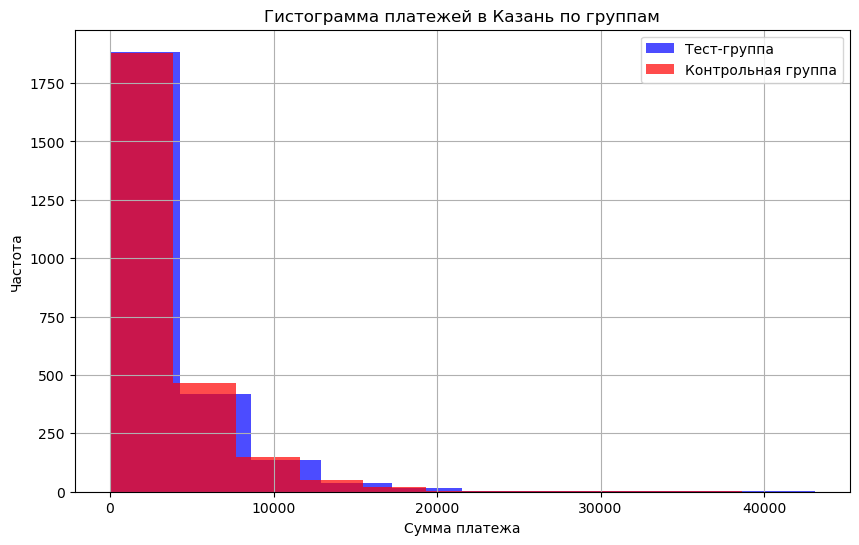

Сравнение средних платежей:
Среднее в контрольной группе: 2610.69
Среднее в тест‑группе: 2731.91
Разница: +4.64%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.47
Среднее в тест‑группе: 0.48
Разница: +0.81%

Критерий Манна‑Уитни для платежей:
Статистика U: 3178575.00
p‑значение: 0.3773
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Саратов


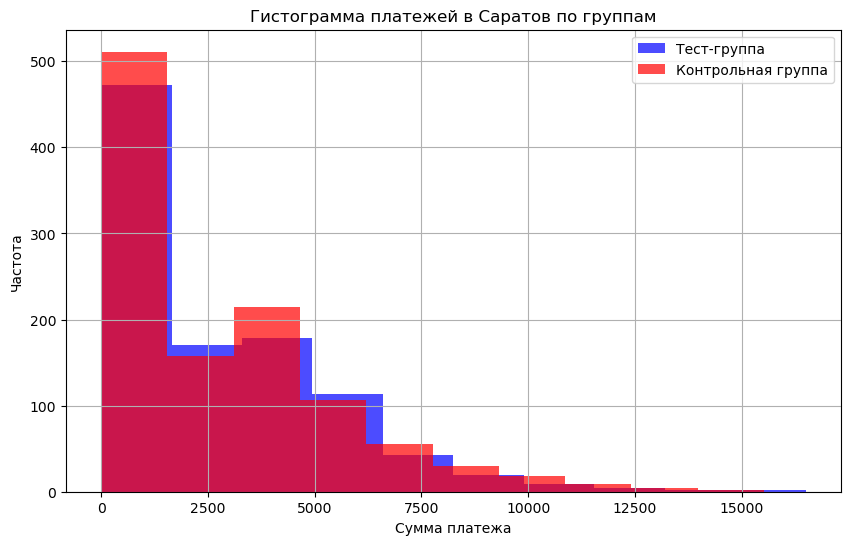

Сравнение средних платежей:
Среднее в контрольной группе: 2541.65
Среднее в тест‑группе: 2528.79
Разница: -0.51%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.57
Среднее в тест‑группе: 0.59
Разница: +2.43%

Критерий Манна‑Уитни для платежей:
Статистика U: 557976.50
p‑значение: 0.7833
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Тольятти


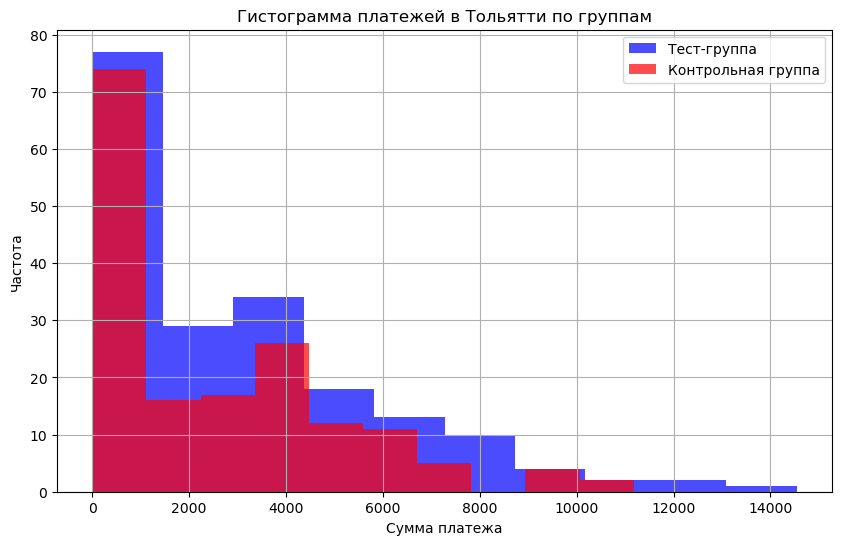

Сравнение средних платежей:
Среднее в контрольной группе: 2439.46
Среднее в тест‑группе: 2902.41
Разница: +18.98%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.58
Среднее в тест‑группе: 0.64
Разница: +10.55%

Критерий Манна‑Уитни для платежей:
Статистика U: 14709.50
p‑значение: 0.2213
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Тюмень


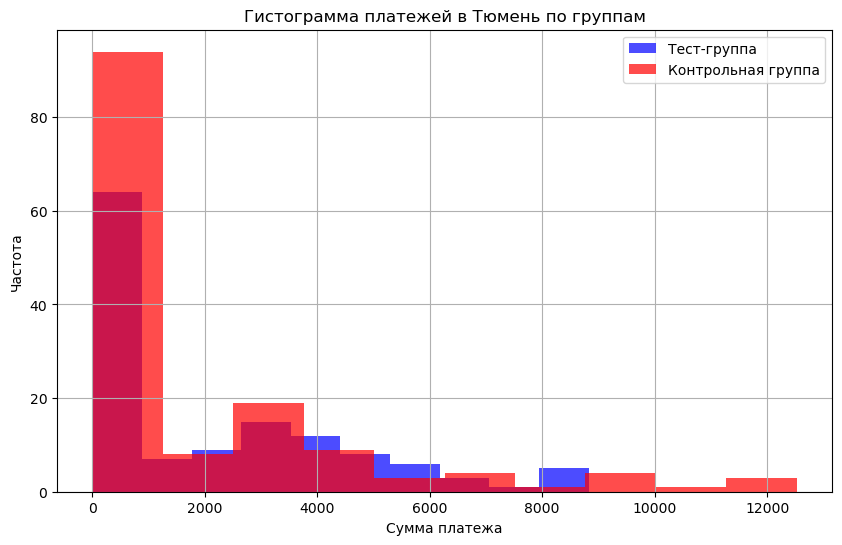

Сравнение средних платежей:
Среднее в контрольной группе: 1743.38
Среднее в тест‑группе: 2043.82
Разница: +17.23%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.38
Среднее в тест‑группе: 0.52
Разница: +38.85%

Критерий Манна‑Уитни для платежей:
Статистика U: 8239.00
p‑значение: 0.0381
Результат статистически значим (p < 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Волгоград


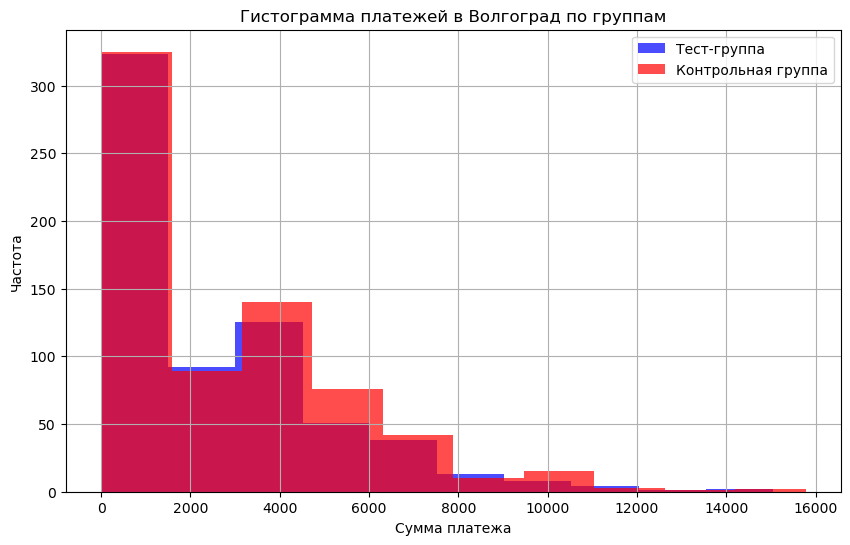

Сравнение средних платежей:
Среднее в контрольной группе: 2601.76
Среднее в тест‑группе: 2288.87
Разница: -12.03%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.60
Среднее в тест‑группе: 0.55
Разница: -7.30%

Критерий Манна‑Уитни для платежей:
Статистика U: 245743.00
p‑значение: 0.0332
Результат статистически значим (p < 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Сочи


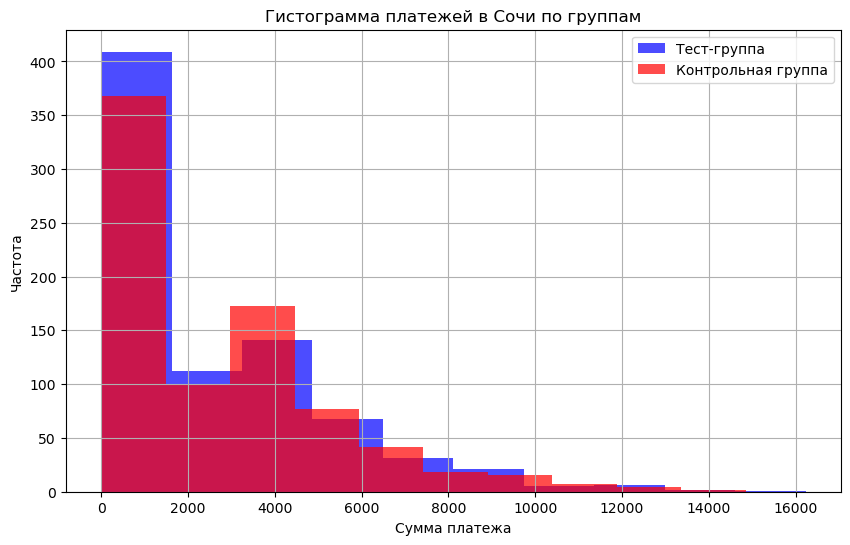

Сравнение средних платежей:
Среднее в контрольной группе: 2523.08
Среднее в тест‑группе: 2305.83
Разница: -8.61%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.57
Среднее в тест‑группе: 0.53
Разница: -8.59%

Критерий Манна‑Уитни для платежей:
Статистика U: 337587.50
p‑значение: 0.0570
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Владимир


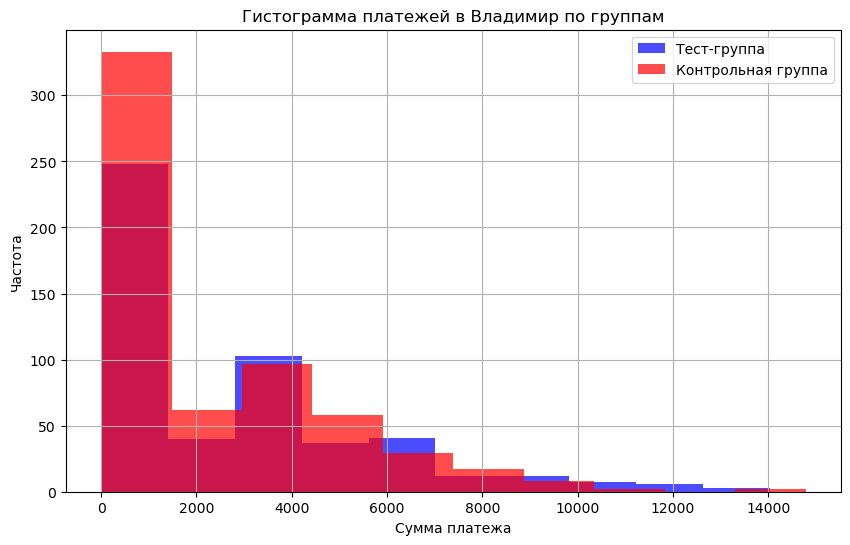

Сравнение средних платежей:
Среднее в контрольной группе: 2108.61
Среднее в тест‑группе: 2547.22
Разница: +20.80%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.50
Среднее в тест‑группе: 0.55
Разница: +10.38%

Критерий Манна‑Уитни для платежей:
Статистика U: 143847.00
p‑значение: 0.0317
Результат статистически значим (p < 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Самара


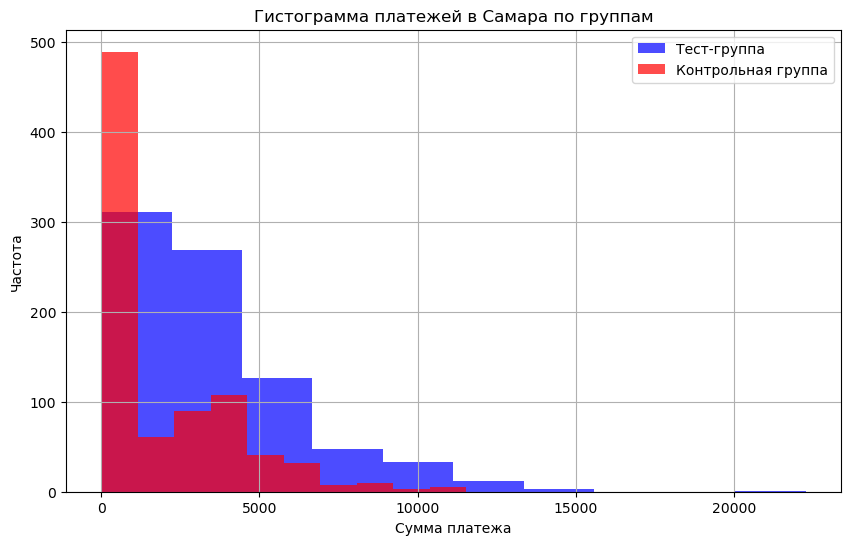

Сравнение средних платежей:
Среднее в контрольной группе: 1718.42
Среднее в тест‑группе: 3262.79
Разница: +89.87%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.44
Среднее в тест‑группе: 0.72
Разница: +63.05%

Критерий Манна‑Уитни для платежей:
Статистика U: 233516.50
p‑значение: 0.0000
Результат статистически значим (p < 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Краснодар


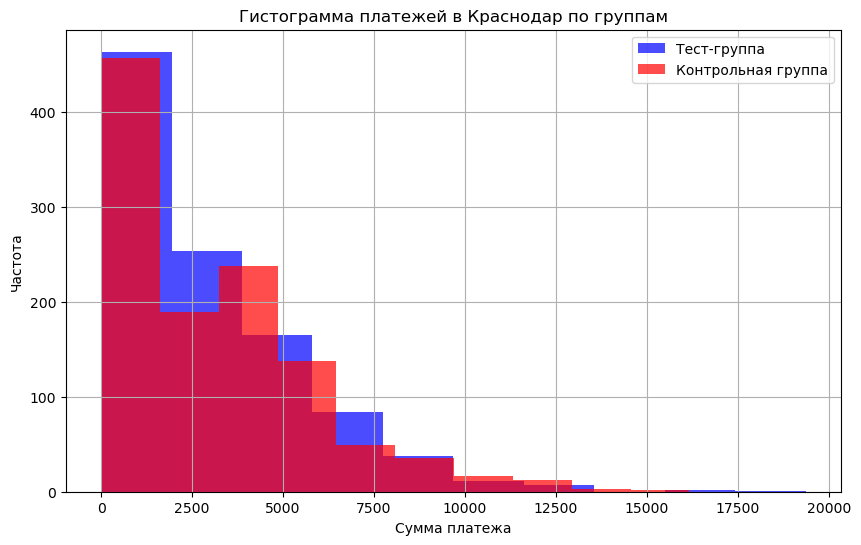

Сравнение средних платежей:
Среднее в контрольной группе: 2912.43
Среднее в тест‑группе: 2696.80
Разница: -7.40%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.65
Среднее в тест‑группе: 0.61
Разница: -5.96%

Критерий Манна‑Уитни для платежей:
Статистика U: 609837.00
p‑значение: 0.0594
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Сахалинск


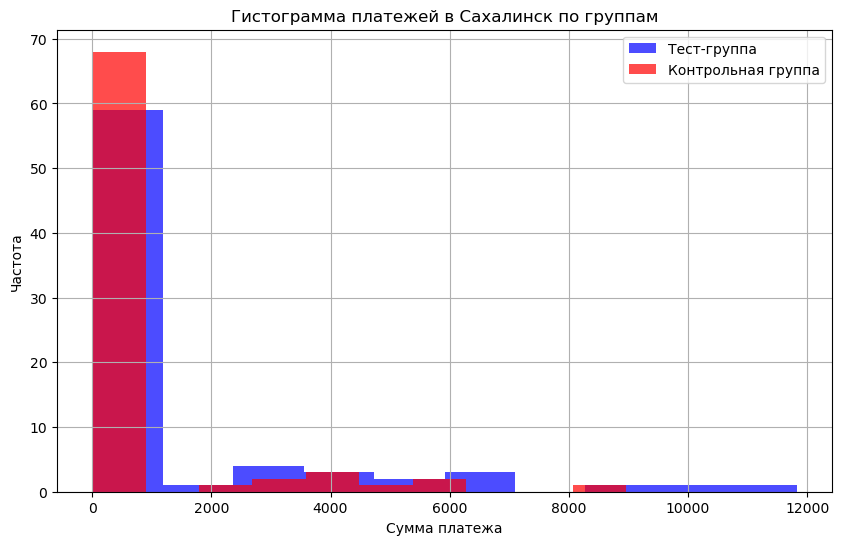

Сравнение средних платежей:
Среднее в контрольной группе: 600.15
Среднее в тест‑группе: 1171.45
Разница: +95.19%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.14
Среднее в тест‑группе: 0.21
Разница: +51.27%

Критерий Манна‑Уитни для платежей:
Статистика U: 2690.50
p‑значение: 0.1987
Нет статистически значимой разницы (p ≥ 0.05)


АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: Дмитров


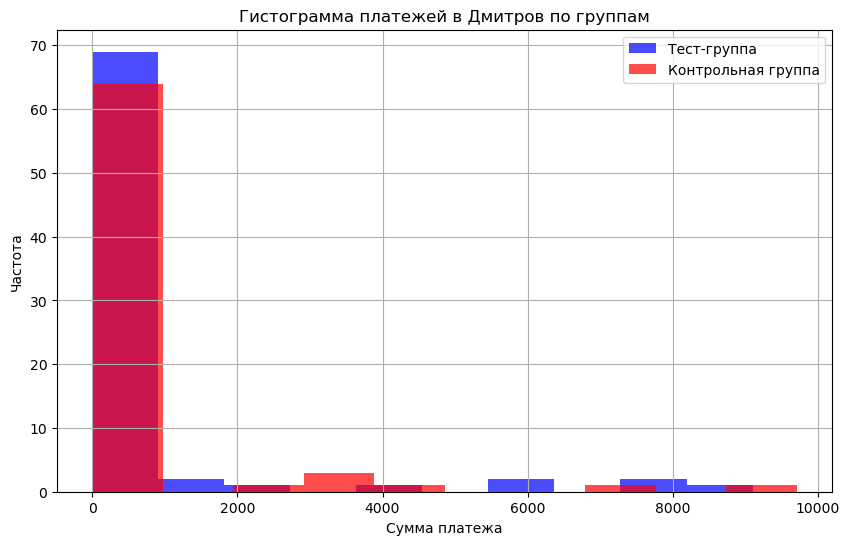

Сравнение средних платежей:
Среднее в контрольной группе: 483.45
Среднее в тест‑группе: 579.33
Разница: +19.83%

Сравнение конверсии в платёж:
Среднее в контрольной группе: 0.10
Среднее в тест‑группе: 0.12
Разница: +17.03%

Критерий Манна‑Уитни для платежей:
Статистика U: 2722.00
p‑значение: 0.7423
Нет статистически значимой разницы (p ≥ 0.05)




In [34]:
# Все города кроме Москвы и СПБ
# Функция для расчёта и вывода статистики
def test_calc(control, test):
    control_mean = control.mean()
    test_mean = test.mean()
    diff = ((test_mean - control_mean) / control_mean * 100) if control_mean != 0 else np.inf
    print(f"Среднее в контрольной группе: {control_mean:.2f}")
    print(f"Среднее в тест‑группе: {test_mean:.2f}")
    print(f"Разница: {diff:+.2f}%")

# Функция для критерия Манна‑Уитни
def mann_whitney_func(control, test):
    stat, p_value = mannwhitneyu(control, test, alternative='two-sided')
    print(f"Статистика U: {stat:.2f}")
    print(f"p‑значение: {p_value:.4f}")
    if p_value < 0.05:
        print("Результат статистически значим (p < 0.05)")
    else:
        print("Нет статистически значимой разницы (p ≥ 0.05)")

# Фильтруем города, исключая Москву и Санкт-Петербург
cities_to_process = filtered_df[~filtered_df['city'].isin(['Москва', 'Санкт-Петербург'])]['city'].unique()

# Основной цикл по городам
for city in cities_to_process:
    print("=" * 60)
    print(f"АНАЛИЗ A/B-ТЕСТА ДЛЯ ГОРОДА: {city}")
    print("=" * 60)

    # Выбираем данные только для текущего города
    city_data = filtered_df[filtered_df['city'] == city]

    # Разделяем данные на группы
    test_group = city_data[city_data['nflag_test'] == 1]
    control_group = city_data[city_data['nflag_test'] == 0]

    # Проверяем, есть ли данные в обеих группах
    if len(test_group) == 0 or len(control_group) == 0:
        print(f"Недостаточно данных для A/B‑теста в городе {city}. Пропускаем...")
        continue

    # Строим гистограмму
    plt.figure(figsize=(10, 6))
    plt.hist(test_group['amt_payment'], alpha=0.7, label='Тест‑группа', color='blue', bins=10)
    plt.hist(control_group['amt_payment'], alpha=0.7, label='Контрольная группа', color='red', bins=10)
    plt.title(f'Гистограмма платежей в {city} по группам')
    plt.xlabel('Сумма платежа')
    plt.ylabel('Частота')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Анализ результатов A/B‑теста
    # Сравнение средних платежей
    test_payments = city_data[city_data['nflag_test'] == 1]['amt_payment']
    control_payments = city_data[city_data['nflag_test'] == 0]['amt_payment']
    print("Сравнение средних платежей:")
    test_calc(control_payments, test_payments)

    # Сравнение конверсии в платёж
    # Создаём бинарные ряды для конверсии (1 — был платёж, 0 — не было)
    test_conversion = (city_data[city_data['nflag_test'] == 1]['flag_payment'] == 1).astype(int)
    control_conversion = (city_data[city_data['nflag_test'] == 0]['flag_payment'] == 1).astype(int)
    print("\nСравнение конверсии в платёж:")
    test_calc(control_conversion, test_conversion)

    # Критерий Манна‑Уитни для распределений платежей
    print("\nКритерий Манна‑Уитни для платежей:")
    mann_whitney_func(control_payments, test_payments)
    print("\n")

In [35]:
# Подготовка пустого датафрейма для результатов
result_columns = [
    'city', 'id_trading_point', 'count_test', 'count_control',
    'count_all', 'percent_count', 'avg_payment_test', 'avg_payment_control',
    'diff', 'sigma_test', 'sigma_control', 'ttest', 'pvalue_ttest', 'label'
]

result_df = pd.DataFrame(columns=result_columns)


In [36]:
# Функция для определения лейбла
def get_label(diff, pvalue):
    alpha = 0.05  # уровень значимости
    if pvalue < alpha:
        if diff > 0:
            return 'положительный'
        else:
            return 'отрицательный'
    else:
        return 'нейтральный'


In [37]:
# Основной цикл обработки
# Получаем уникальные комбинации город-торговая точка
unique_combinations = filtered_df[['city', 'id_trading_point']].drop_duplicates()

# Общее количество наблюдений для расчёта процента
total_observations = len(filtered_df)

for _, row in unique_combinations.iterrows():
    city = row['city']
    trading_point = row['id_trading_point']
    
    # Фильтруем данные для текущей торговой точки
    tp_data = filtered_df[
        (filtered_df['city'] == city) &
        (filtered_df['id_trading_point'] == trading_point)
    ]
    
    # Разделяем на тестовую и контрольную группы
    test_group = tp_data[tp_data['nflag_test'] == 1]
    control_group = tp_data[tp_data['nflag_test'] == 0]
    
    # Считаем базовые статистики
    count_test = len(test_group)
    count_control = len(control_group)
    count_all = count_test + count_control
    percent_count = (count_all / total_observations) * 100
    
    # Средние платежи и стандартные отклонения
    avg_payment_test = test_group['amt_payment'].mean() if count_test > 0 else 0
    avg_payment_control = control_group['amt_payment'].mean() if count_control > 0 else 0
    sigma_test = test_group['amt_payment'].std() if count_test > 1 else 0
    sigma_control = control_group['amt_payment'].std() if count_control > 1 else 0
    
    # Разница между средними
    diff = avg_payment_test - avg_payment_control
    
    # Критерий Стьюдента
    if count_test > 0 and count_control > 0:
        ttest_result = stats.ttest_ind(
            test_group['amt_payment'],
            control_group['amt_payment'],
            equal_var=False  # используем тест Уэлча
        )
        ttest = ttest_result.statistic
        pvalue_ttest = ttest_result.pvalue
    else:
        ttest = np.nan
        pvalue_ttest = np.nan
    
    # Определяем лейбл
    label = get_label(diff, pvalue_ttest)
    
    # Добавляем строку в итоговый датафрейм
    new_row = pd.DataFrame([{
        'city': city,
        'id_trading_point': trading_point,
        'count_test': count_test,
        'count_control': count_control,
        'count_all': count_all,
        'percent_count': percent_count,
        'avg_payment_test': avg_payment_test,
        'avg_payment_control': avg_payment_control,
        'diff': diff,
        'sigma_test': sigma_test,
        'sigma_control': sigma_control,
        'ttest': ttest,
        'pvalue_ttest': pvalue_ttest,
        'label': label
    }])
    
    result_df = pd.concat([result_df, new_row], ignore_index=True)


C:\Users\CDM5\AppData\Local\Temp\ipykernel_8828\10095495.py:70: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, new_row], ignore_index=True)


In [38]:
# Выгрузка в Excel с разделением по лейблам
# Разделяем датафрейм по лейблам
positive_df = result_df[result_df['label'] == 'положительный']
negative_df = result_df[result_df['label'] == 'отрицательный']
neutral_df = result_df[result_df['label'] == 'нейтральный']

# Создаём Excel writer
with pd.ExcelWriter('results_by_labels.xlsx', engine='xlsxwriter') as writer:
    # Записываем каждый датафрейм на отдельный лист
    positive_df.to_excel(writer, sheet_name='Положительные', index=False)
    negative_df.to_excel(writer, sheet_name='Отрицательные', index=False)
    neutral_df.to_excel(writer, sheet_name='Нейтральные', index=False)

print("Результаты успешно выгружены в файл 'results_by_labels.xlsx'")


Результаты успешно выгружены в файл 'results_by_labels.xlsx'
